/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_23902/1479408076.py:361: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


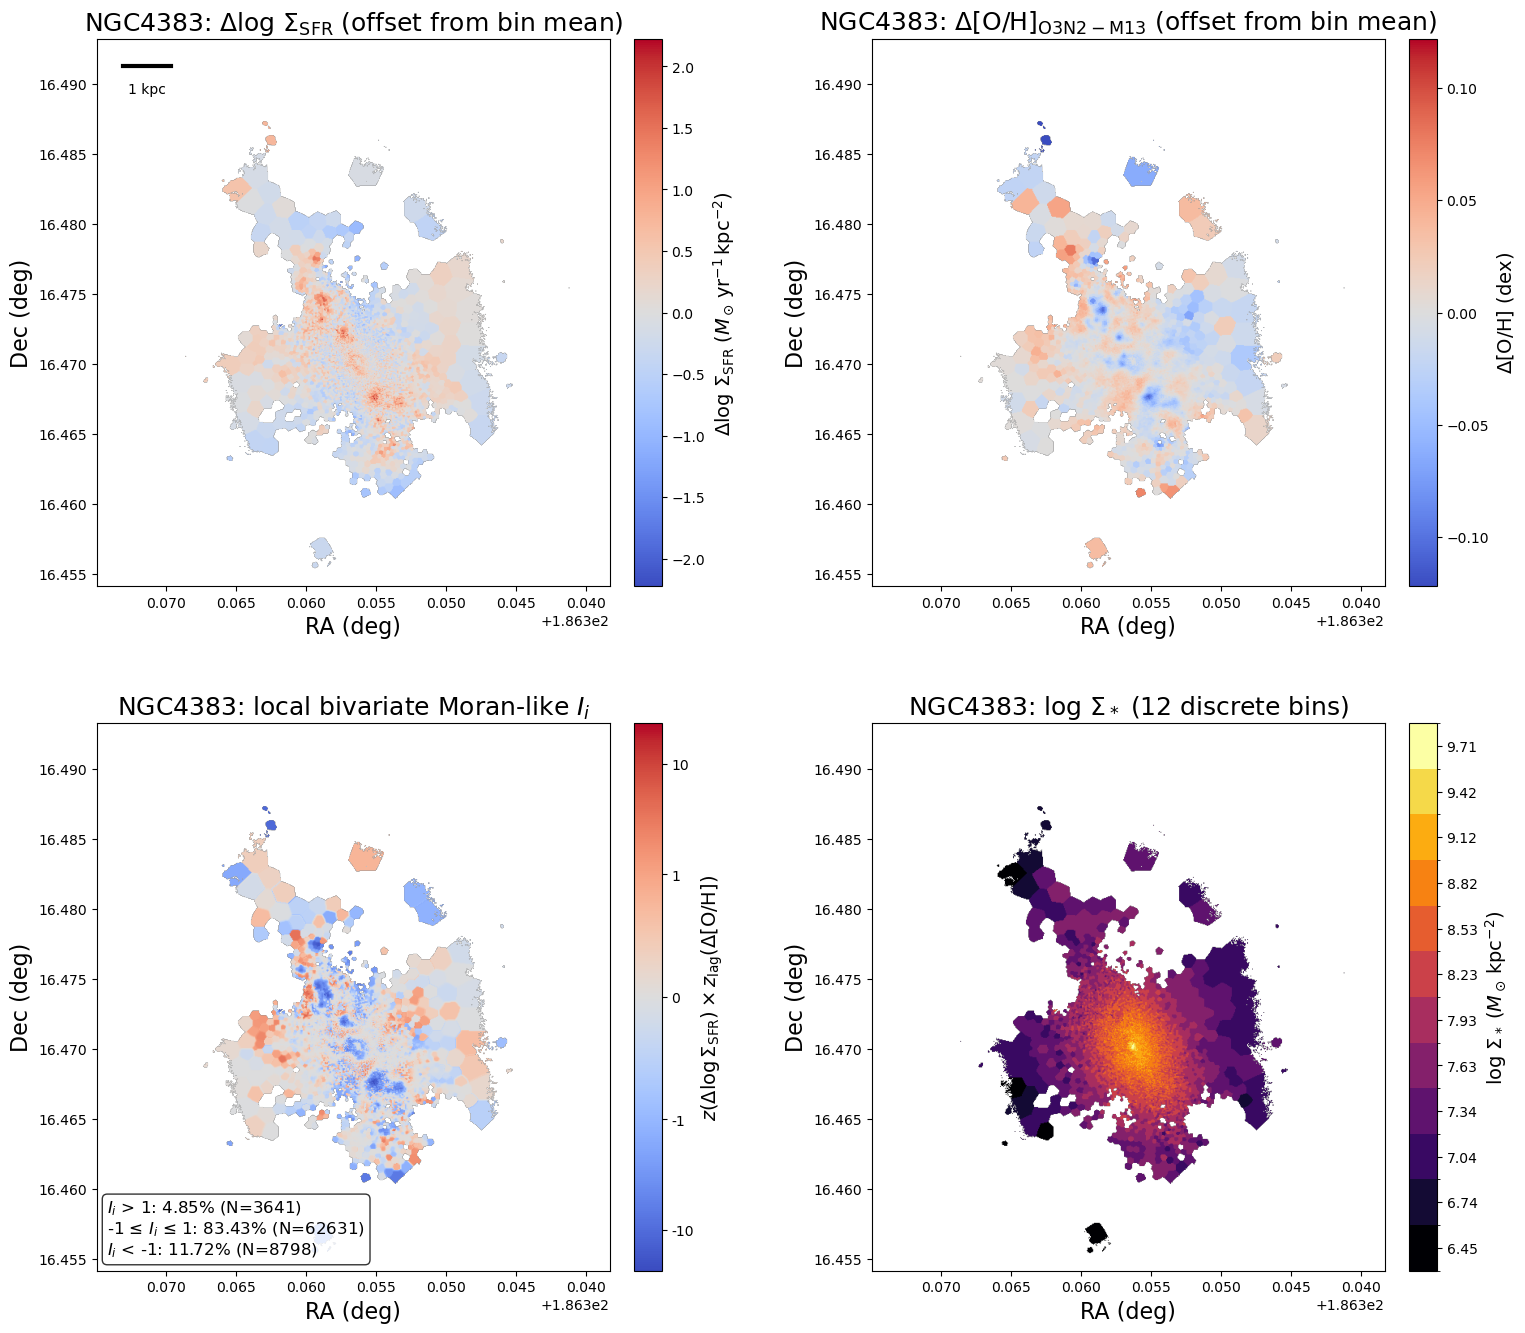


2x2 combined figure complete for NGC4383!
  Σ_SFR offset range: -2.225 to 2.225
  [O/H] offset range: -0.122 to 0.122
  Moran I_i range: -23.521 to 5.244
  Σ* bins: 12 bins from 6.300 to 9.860
  I_i > 1: 4.85% (N=3641)
  -1 ≤ I_i ≤ 1: 83.43% (N=62631)
  I_i < -1: 11.72% (N=8798)


In [1]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    add_scalebar(ax1, scalebar_length_deg, label='1 kpc')
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    # plt.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")